# **Employee Performance and Retention Analysis**

**Phase 1 - Data Collection and Exploratory Data Analysis (EDA)**

**Step 1 - Data Collection and Preprocessing**
- **Dataset -** Use a sample employee dataset. The dataset should contain features such as:
  - Employee ID
  - Name
  - Age
  - Department
  - Salary
  - Years at Company
  - Performance Score
  - Attrition (Yes/No)

- **Tasks -**
   - Load the dataset (Employee_data.csv)  using Pandas.
  - Handle missing values, remove duplicates, and clean inconsistent data entries.


In [1]:
# importing libraries Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow / Keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf
from tensorflow import keras

In [2]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Check the uploaded file(s)
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving employee_data.csv to employee_data (2).csv
User uploaded file "employee_data (2).csv" with length 4386 bytes


In [3]:
df = pd.read_csv('employee_data.csv')

In [4]:
df.head()

,EmployeeID,Name,Age,Department,Salary,YearsAtCompany,PerformanceScore,Attrition
0,1,John Doe,29,Sales,55000,3,80,No
1,2,Jane Smith,35,HR,60000,7,85,No
2,3,Michael Brown,40,Engineering,80000,10,95,Yes
3,4,Emily Davis,28,Marketing,65000,5,78,No
4,5,David Johnson,50,Sales,75000,20,88,Yes


In [5]:
# Handle missing values, remove duplicates, and clean inconsistent data entries.
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,0
Department,0
Salary,0
YearsAtCompany,0
PerformanceScore,0
Attrition,0


**Step 2 - Exploratory Data Analysis (EDA)**
- **Objective -** Perform an initial analysis to understand the dataset and its key trends.


- **Tasks -**


  - Calculate descriptive statistics like mean, median, mode, variance, and standard deviation for numerical columns.
  - Use Matplotlib and Seaborn to visualize:
    - Pairplot to explore relationships between multiple features.
    - Heatmap for correlation analysis.
    - Identify any outliers in numerical features (using boxplots).


In [6]:
# Calculate descriptive statistics like mean, median, mode, variance, and standard deviation for numerical columns.
numerical_cols = ['Age', 'Salary', 'YearsAtCompany', 'PerformanceScore']

for col in numerical_cols:
    print(f"\nDescriptive Statistics for {col}:")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    # Mode can return multiple values, so we display all
    mode_val = df[col].mode()
    if not mode_val.empty:
        print(f"Mode: {', '.join(map(str, mode_val.tolist()))}")
    else:
        print("Mode: Not applicable (no unique mode)")
    print(f"Variance: {df[col].var():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")



Descriptive Statistics for Age:
Mean: 36.57
Median: 35.00
Mode: 29
Variance: 69.20
Standard Deviation: 8.32

Descriptive Statistics for Salary:
Mean: 72820.00
Median: 72000.00
Mode: 68000, 69000, 70000, 87000
Variance: 159866262.63
Standard Deviation: 12643.82

Descriptive Statistics for YearsAtCompany:
Mean: 10.80
Median: 10.00
Mode: 2, 3, 4, 5, 8, 10, 12, 18, 20
Variance: 40.46
Standard Deviation: 6.36

Descriptive Statistics for PerformanceScore:
Mean: 84.94
Median: 85.50
Mode: 80
Variance: 40.32
Standard Deviation: 6.35


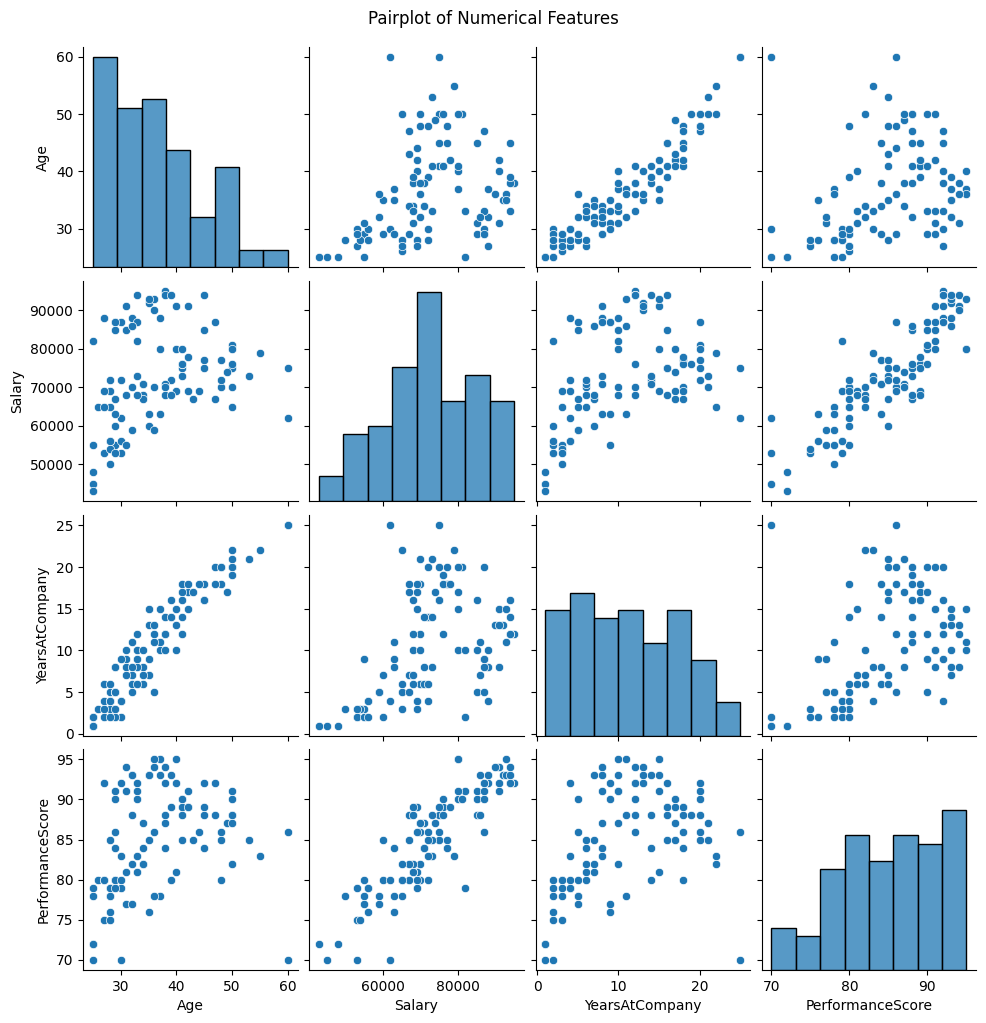

In [7]:
# Use Matplotlib and Seaborn to visualize:
#     Pairplot to explore relationships between multiple features.
#     Heatmap for correlation analysis.
#     Identify any outliers in numerical features (using boxplots).

import seaborn as sns
import matplotlib.pyplot as plt

# Numerical columns identified previously
numerical_cols = ['Age', 'Salary', 'YearsAtCompany', 'PerformanceScore']

sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust title position
plt.show()

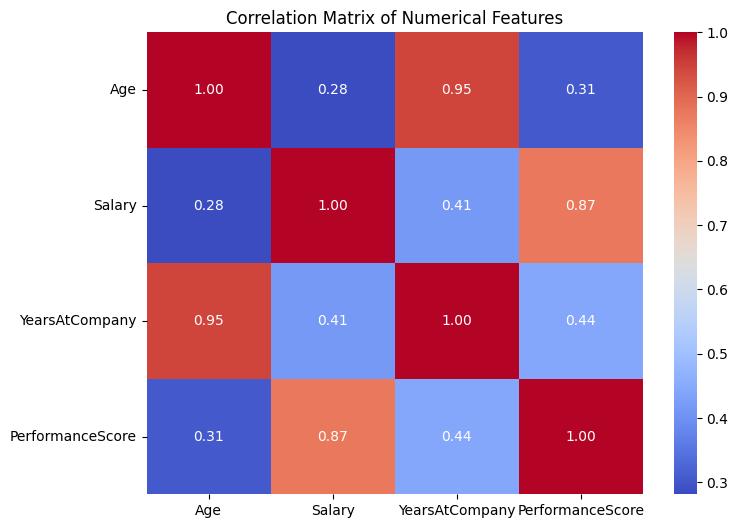

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

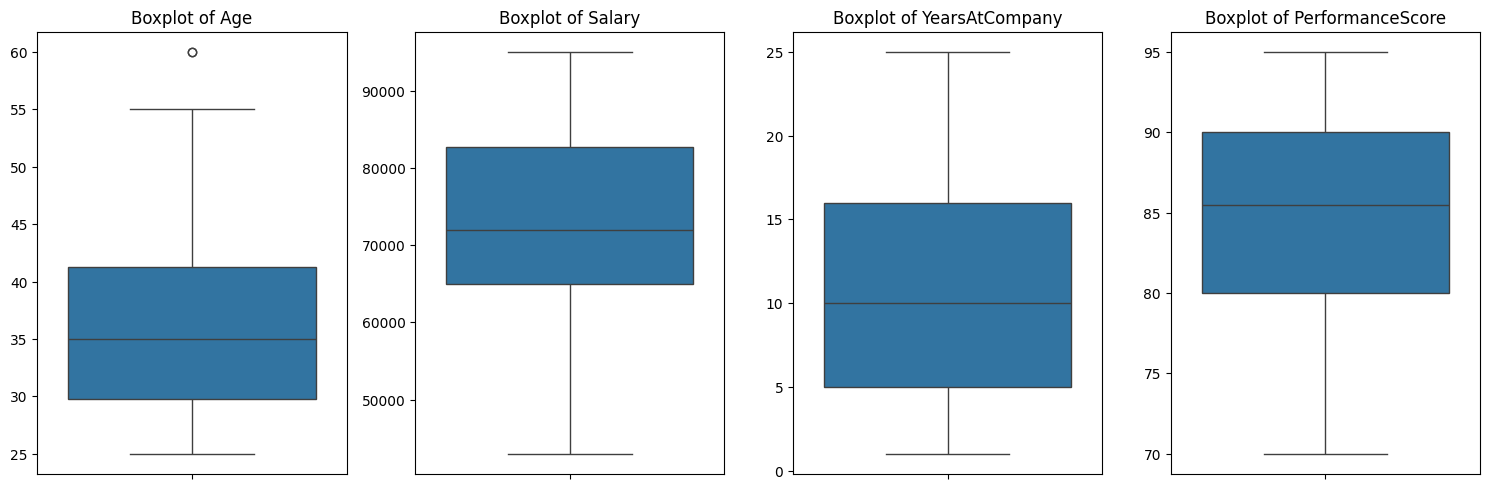

In [9]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

**Step 3 - Probability and Statistical Analysis**

- **Objective -** Apply probability concepts and statistical tests to better understand the dataset.

- **Tasks -**


    - **Probability -** Calculate the probability of an employee leaving based on factors like performance scores and department.
    - **Bayes' Theorem -** Use Bayes' Theorem to find the probability of employee attrition given performance score.
    - **Hypothesis Testing -** Test whether the mean performance score differs across departments.



In [10]:
# Probability - Calculate the probability of an employee leaving based on factors like performance scores and department.
p_attrition = (df['Attrition'] == 'Yes').mean()
print(f"Overall Probability of Attrition: {p_attrition:.3f}")

Overall Probability of Attrition: 0.390


In [11]:
p_attrition_by_dept = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean())
print("\nAttrition Probability by Department:")
print(p_attrition_by_dept.sort_values(ascending=False))


Attrition Probability by Department:
Department
Sales          0.538462
Engineering    0.428571
HR             0.346154
Marketing      0.200000
Name: Attrition, dtype: float64



Attrition Probability by Department:
Department
Sales          0.538462
Engineering    0.428571
HR             0.346154
Marketing      0.200000
Name: Attrition, dtype: float64


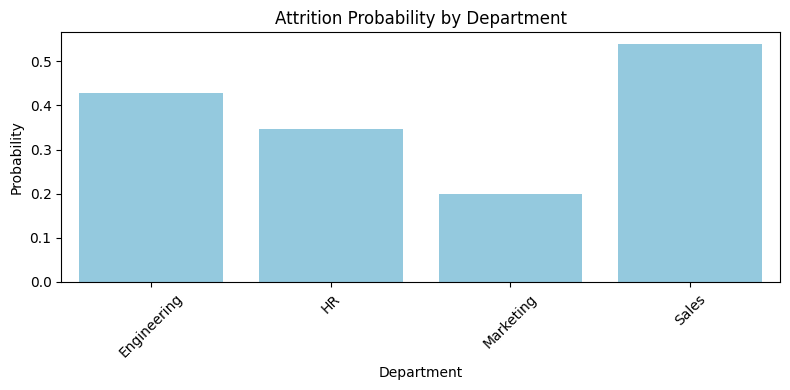

/tmp/ipython-input-2812936649.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_attrition_by_perf = df.groupby('Perf_bin')['Attrition'].apply(lambda x: (x == 'Yes').mean())



Attrition Probability by Performance Range:
Perf_bin
>90      0.500000
81–90    0.413043
61–70    0.333333
71–80    0.259259
<=60          NaN
Name: Attrition, dtype: float64


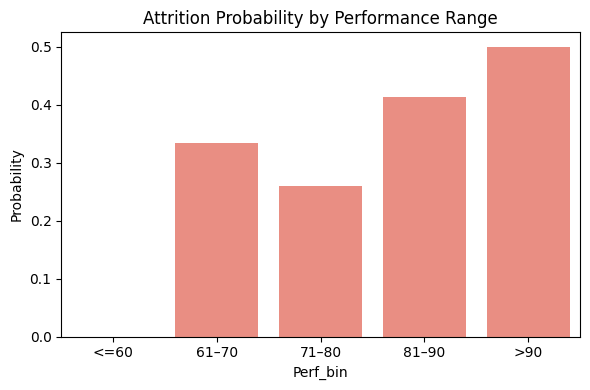

In [15]:
df['Perf_bin'] = pd.cut(
    df['PerformanceScore'], # Corrected column name
    bins=[-np.inf, 60, 70, 80, 90, np.inf],
    labels=['<=60', '61–70', '71–80', '81–90', '>90']
)

# Probability by Department (already calculated correctly, but including for completeness with corrected Perf_bin creation)
p_attrition_by_dept = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean())
print("\nAttrition Probability by Department:")
print(p_attrition_by_dept.sort_values(ascending=False))

# Plot: Department-wise
plt.figure(figsize=(8,4))
sns.barplot(x=p_attrition_by_dept.index, y=p_attrition_by_dept.values, color='skyblue')
plt.title('Attrition Probability by Department')
plt.ylabel('Probability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Probability by Performance bin (recalculated with corrected column name)
p_attrition_by_perf = df.groupby('Perf_bin')['Attrition'].apply(lambda x: (x == 'Yes').mean())
print("\nAttrition Probability by Performance Range:")
print(p_attrition_by_perf.sort_values(ascending=False))

# Plot: Performance range
plt.figure(figsize=(6,4))
sns.barplot(x=p_attrition_by_perf.index, y=p_attrition_by_perf.values, color='salmon')
plt.title('Attrition Probability by Performance Range')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()


Attrition Probability by Department:
Department
Sales          0.538462
Engineering    0.428571
HR             0.346154
Marketing      0.200000
Name: Attrition, dtype: float64


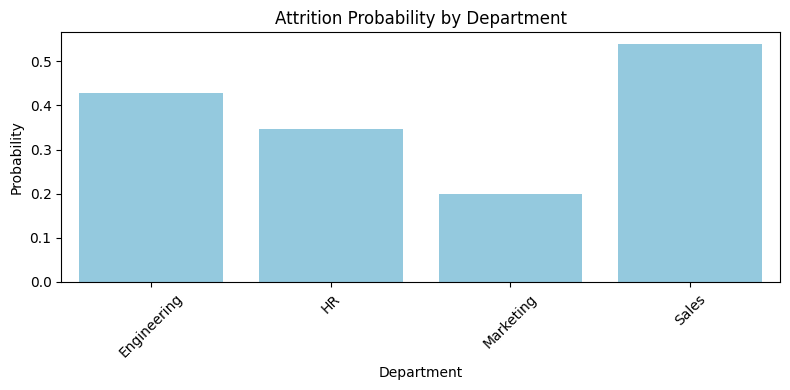


Attrition Probability by Performance Range:
Perf_bin
>90      0.500000
81–90    0.413043
61–70    0.333333
71–80    0.259259
<=60          NaN
Name: Attrition, dtype: float64


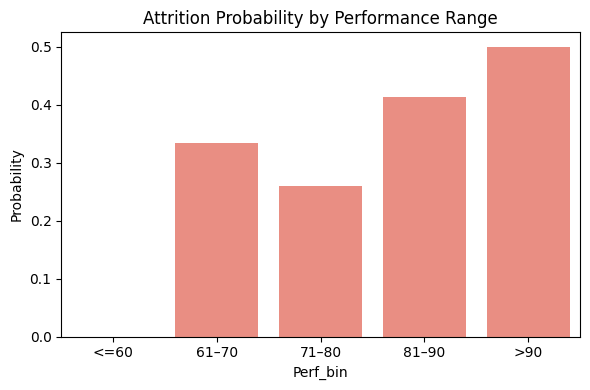

In [16]:
df['Perf_bin'] = pd.cut(
    df['PerformanceScore'], # Corrected column name
    bins=[-np.inf, 60, 70, 80, 90, np.inf],
    labels=['<=60', '61–70', '71–80', '81–90', '>90']
)

# Probability by Department (already calculated correctly, but including for completeness with corrected Perf_bin creation)
p_attrition_by_dept = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean())
print("\nAttrition Probability by Department:")
print(p_attrition_by_dept.sort_values(ascending=False))

# Plot: Department-wise
plt.figure(figsize=(8,4))
sns.barplot(x=p_attrition_by_dept.index, y=p_attrition_by_dept.values, color='skyblue')
plt.title('Attrition Probability by Department')
plt.ylabel('Probability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Probability by Performance bin (recalculated with corrected column name)
p_attrition_by_perf = df.groupby('Perf_bin', observed=False)['Attrition'].apply(lambda x: (x == 'Yes').mean()) # Added observed=False
print("\nAttrition Probability by Performance Range:")
print(p_attrition_by_perf.sort_values(ascending=False))

# Plot: Performance range
plt.figure(figsize=(6,4))
sns.barplot(x=p_attrition_by_perf.index, y=p_attrition_by_perf.values, color='salmon')
plt.title('Attrition Probability by Performance Range')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

In [17]:
print("--- Applying Bayes' Theorem for Attrition ---")

# 1. Calculate the prior probability of attrition (P(Attrition=Yes)) and non-attrition (P(Attrition=No)).
p_attrition_yes = (df['Attrition'] == 'Yes').mean()
p_attrition_no = 1 - p_attrition_yes

print(f"\nPrior Probability of Attrition (P(Attrition=Yes)): {p_attrition_yes:.3f}")
print(f"Prior Probability of Non-Attrition (P(Attrition=No)): {p_attrition_no:.3f}")

# 2. Calculate the marginal probability of employees falling into the '>90' performance score range (P(PerformanceScore='>90')).
# Ensure 'Perf_bin' is correctly created and includes the '>90' category
if 'Perf_bin' not in df.columns:
    df['Perf_bin'] = pd.cut(
        df['PerformanceScore'],
        bins=[-np.inf, 60, 70, 80, 90, np.inf],
        labels=['<=60', '61–70', '71–80', '81–90', '>90']
    )

p_perf_gt90 = (df['Perf_bin'] == '>90').mean()
print(f"Marginal Probability of Performance Score >90 (P(Perf='>90')): {p_perf_gt90:.3f}")

# 3. Calculate the likelihood of having a performance score in the '>90' range given attrition (P(PerformanceScore='>90' | Attrition=Yes)).
subset_attrition_yes = df[df['Attrition'] == 'Yes']
# Ensure we handle cases where the subset might be empty to avoid division by zero if there are no 'Yes' attritions
if not subset_attrition_yes.empty:
    p_perf_gt90_given_attrition_yes = (subset_attrition_yes['Perf_bin'] == '>90').mean()
else:
    p_perf_gt90_given_attrition_yes = 0.0 # If no attrition, then this likelihood is 0
print(f"Likelihood P(Perf='>90' | Attrition=Yes): {p_perf_gt90_given_attrition_yes:.3f}")

# 4. Calculate the likelihood of having a performance score in the '>90' range given non-attrition (P(PerformanceScore='>90' | Attrition=No)).
subset_attrition_no = df[df['Attrition'] == 'No']
if not subset_attrition_no.empty:
    p_perf_gt90_given_attrition_no = (subset_attrition_no['Perf_bin'] == '>90').mean()
else:
    p_perf_gt90_given_attrition_no = 0.0 # If no non-attrition, then this likelihood is 0
print(f"Likelihood P(Perf='>90' | Attrition=No): {p_perf_gt90_given_attrition_no:.3f}")

# 5. Apply Bayes' Theorem to compute the posterior probability of attrition given a performance score in the '>90' range (P(Attrition=Yes | PerformanceScore='>90')).
# P(Attrition=Yes | Perf='>90') = [P(Perf='>90' | Attrition=Yes) * P(Attrition=Yes)] / P(Perf='>90')

if p_perf_gt90 > 0:
    p_attrition_yes_given_perf_gt90 = (p_perf_gt90_given_attrition_yes * p_attrition_yes) / p_perf_gt90
else:
    p_attrition_yes_given_perf_gt90 = 0.0 # Cannot calculate if P(Perf='>90') is zero

print(f"\nPosterior Probability P(Attrition=Yes | Perf='>90'): {p_attrition_yes_given_perf_gt90:.3f}")

--- Applying Bayes' Theorem for Attrition ---

Prior Probability of Attrition (P(Attrition=Yes)): 0.390
Prior Probability of Non-Attrition (P(Attrition=No)): 0.610
Marginal Probability of Performance Score >90 (P(Perf='>90')): 0.240
Likelihood P(Perf='>90' | Attrition=Yes): 0.308
Likelihood P(Perf='>90' | Attrition=No): 0.197

Posterior Probability P(Attrition=Yes | Perf='>90'): 0.500


In [18]:
print("--- Performing Hypothesis Testing (ANOVA) ---")

from scipy import stats

# Create a list of performance scores grouped by department
departments = df['Department'].unique()
performance_scores_by_department = [df['PerformanceScore'][df['Department'] == dept] for dept in departments]

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(*performance_scores_by_department)

print(f"\nANOVA F-statistic: {f_statistic:.3f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in mean performance scores across different departments.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in mean performance scores across different departments.")

--- Performing Hypothesis Testing (ANOVA) ---

ANOVA F-statistic: 25.781
ANOVA P-value: 0.000
Since the p-value (0.000) is less than alpha (0.05), we reject the null hypothesis.
Conclusion: There is a significant difference in mean performance scores across different departments.


--- Visualizing Performance Score Distribution by Department ---


/tmp/ipython-input-923949555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='PerformanceScore', data=df, palette='viridis')


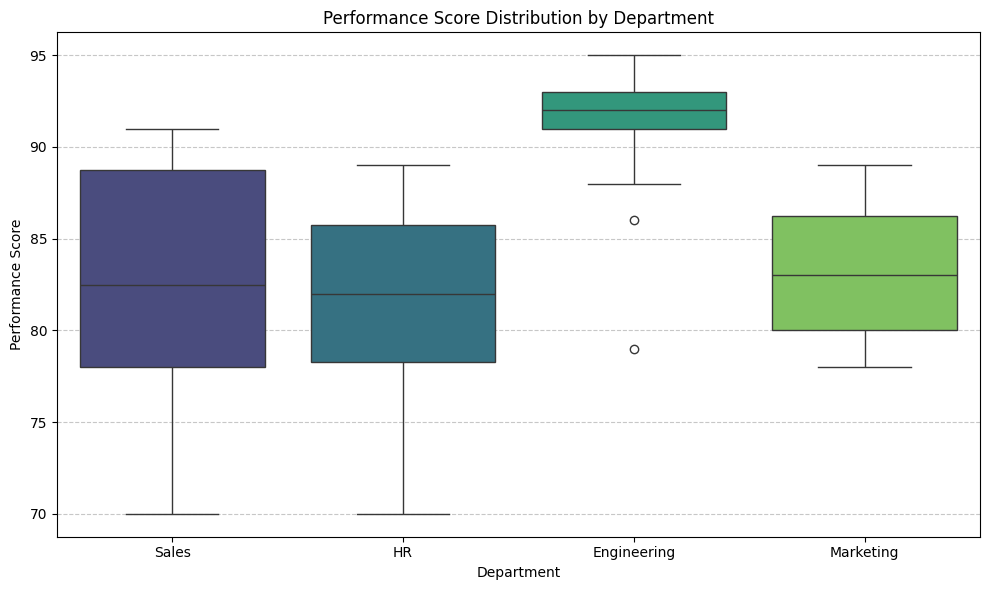

In [19]:
print("--- Visualizing Performance Score Distribution by Department ---")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='PerformanceScore', data=df, palette='viridis')
plt.title('Performance Score Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Performance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Visualizing Performance Score Distribution by Department ---


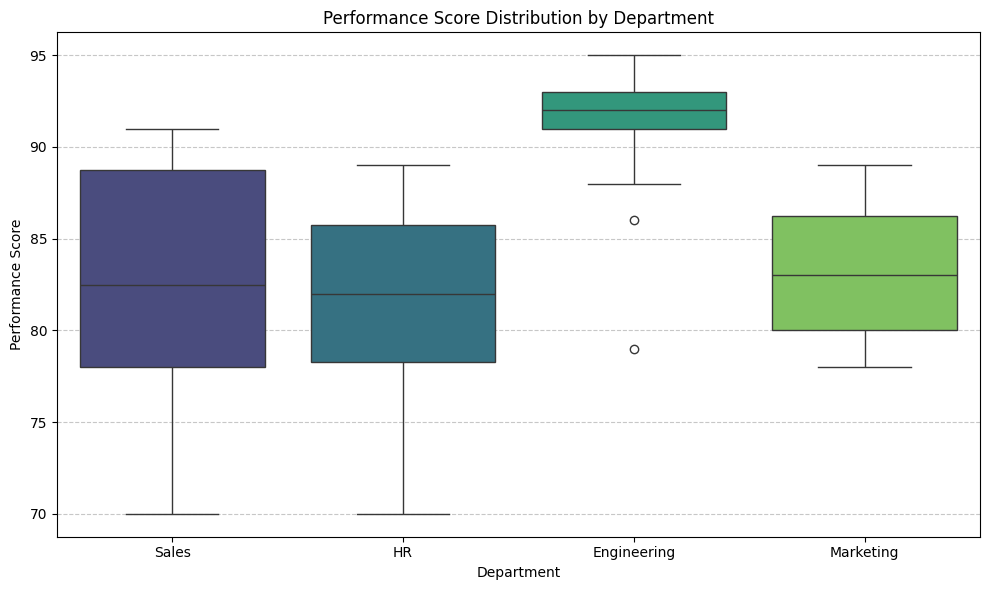

In [20]:
print("--- Visualizing Performance Score Distribution by Department ---")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='PerformanceScore', data=df, palette='viridis', hue='Department', legend=False)
plt.title('Performance Score Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Performance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Phase 2 - Predictive Modeling**

**Step 4 - Feature Engineering and Encoding**

- **Objective** - Prepare the data for machine learning models.


- **Tasks** -
  - Scale numerical features such as Salary and Performance Scores using Min-Max Scaling or Standardization.

  -   Apply Label Encoding to categorical features (e.g., Attrition, Department).


In [22]:
# Scale numerical features such as Salary and Performance Scores using Min-Max Scaling or Standardization.
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Define the numerical columns to be scaled
features_to_scale = ['Salary', 'PerformanceScore']

# Apply Min-Max Scaling
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("DataFrame after Min-Max Scaling for 'Salary' and 'PerformanceScore':")
display(df.head())

DataFrame after Min-Max Scaling for 'Salary' and 'PerformanceScore':


,EmployeeID,Name,Age,Department,Salary,YearsAtCompany,PerformanceScore,Attrition,Perf_bin,PerfBin
0,1,John Doe,29,Sales,0.230769,3,0.40,No,71–80,NaN
1,2,Jane Smith,35,HR,0.326923,7,0.60,No,81–90,NaN
2,3,Michael Brown,40,Engineering,0.711538,10,1.00,Yes,>90,NaN
3,4,Emily Davis,28,Marketing,0.423077,5,0.32,No,71–80,NaN
4,5,David Johnson,50,Sales,0.615385,20,0.72,Yes,81–90,NaN


In [23]:
# Apply Label Encoding to categorical features (e.g., Attrition, Department).
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Define the categorical columns to be encoded
categorical_features = ['Attrition', 'Department']

for col in categorical_features:
    df[col] = le.fit_transform(df[col])
    print(f"Value counts for '{col}' after Label Encoding:")
    print(df[col].value_counts())
    print("\n")

print("DataFrame after Label Encoding for 'Attrition' and 'Department':")
display(df.head())

Value counts for 'Attrition' after Label Encoding:
Attrition
0    61
1    39
Name: count, dtype: int64


Value counts for 'Department' after Label Encoding:
Department
0    28
3    26
1    26
2    20
Name: count, dtype: int64


DataFrame after Label Encoding for 'Attrition' and 'Department':


,EmployeeID,Name,Age,Department,Salary,YearsAtCompany,PerformanceScore,Attrition,Perf_bin,PerfBin
0,1,John Doe,29,3,0.230769,3,0.40,0,71–80,NaN
1,2,Jane Smith,35,1,0.326923,7,0.60,0,81–90,NaN
2,3,Michael Brown,40,0,0.711538,10,1.00,1,>90,NaN
3,4,Emily Davis,28,2,0.423077,5,0.32,0,71–80,NaN
4,5,David Johnson,50,3,0.615385,20,0.72,1,81–90,NaN


**Step 5 - Employee Attrition Prediction Model**

- **Objective** - Build a machine learning model to predict employee attrition (i.e., whether an employee will leave or stay).


- **Tasks -**

  - Split the dataset into training and testing sets using Scikit-learn.
  - Choose a classification model (e.g., Logistic Regression, Random Forest Classifier).
  - Evaluate the model using accuracy, precision, recall, and F1-score.
  - Visualize the confusion matrix to check the model’s performance.

In [26]:
# Split the dataset into training and testing sets using Scikit-learn.

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Select only the relevant numerical and encoded categorical features, explicitly excluding 'Perf_bin'
X = df[['Age', 'Department', 'Salary', 'YearsAtCompany', 'PerformanceScore']]
y = df['Attrition']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80, 5)
Shape of X_test: (20, 5)
Shape of y_train: (80,)
Shape of y_test: (20,)


In [27]:
# Choose a classification model (e.g., Logistic Regression, Random Forest Classifier).

from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [28]:
# Evaluate the model using accuracy, precision, recall, and F1-score.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7000
Precision: 0.7500
Recall: 0.3750
F1-Score: 0.5000


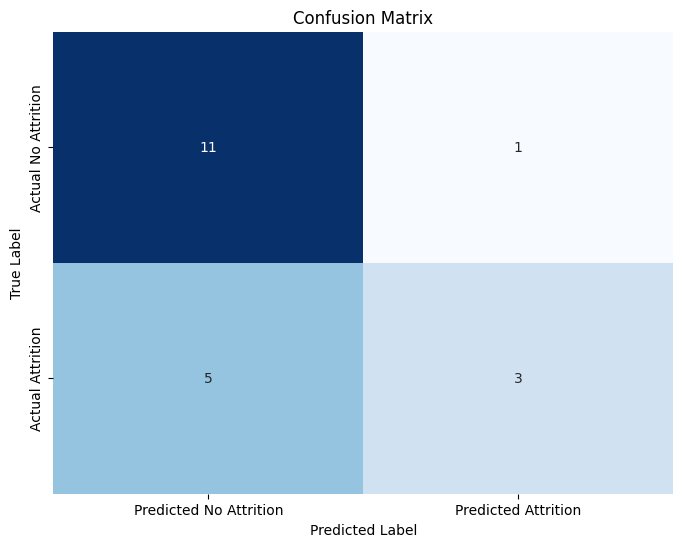

In [29]:
# Visualize the confusion matrix to check the model’s performance.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Attrition', 'Predicted Attrition'],
            yticklabels=['Actual No Attrition', 'Actual Attrition'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Step 6 - Employee Performance Prediction Model**

- **Objective -** Build a regression model to predict employee performance based on various features.


- **Tasks -**


  - Split the dataset into training and testing sets.
  - Build a Linear Regression model to predict Performance Score.
  - Evaluate the model using R-squared (R²) and Mean Squared Error (MSE).
  - Visualize predicted vs. actual performance scores.


In [30]:
# Build a Linear Regression model to predict Performance Score.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X_perf) and target (y_perf) for performance prediction
# Exclude 'EmployeeID', 'Name', 'Attrition', 'Perf_bin', and 'PerformanceScore' itself from features
X_perf = df[['Age', 'Department', 'Salary', 'YearsAtCompany']]
y_perf = df['PerformanceScore']

# Split the dataset into training and testing sets for performance prediction
X_train_perf, X_test_perf, y_train_perf, y_test_perf = train_test_split(X_perf, y_perf, test_size=0.2, random_state=42)

print("Shape of X_train_perf:", X_train_perf.shape)
print("Shape of X_test_perf:", X_test_perf.shape)
print("Shape of y_train_perf:", y_train_perf.shape)
print("Shape of y_test_perf:", y_test_perf.shape)

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model on the training data
linear_model.fit(X_train_perf, y_train_perf)

print("\nLinear Regression model for Performance Score trained successfully.")

Shape of X_train_perf: (80, 4)
Shape of X_test_perf: (20, 4)
Shape of y_train_perf: (80,)
Shape of y_test_perf: (20,)

Linear Regression model for Performance Score trained successfully.


In [31]:
# Evaluate the model using R-squared (R²) and Mean Squared Error (MSE).

from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the test set for performance score
y_pred_perf = linear_model.predict(X_test_perf)

# Calculate R-squared
r_squared = r2_score(y_test_perf, y_pred_perf)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test_perf, y_pred_perf)

print(f"R-squared (R²): {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared (R²): 0.7515
Mean Squared Error (MSE): 0.0203


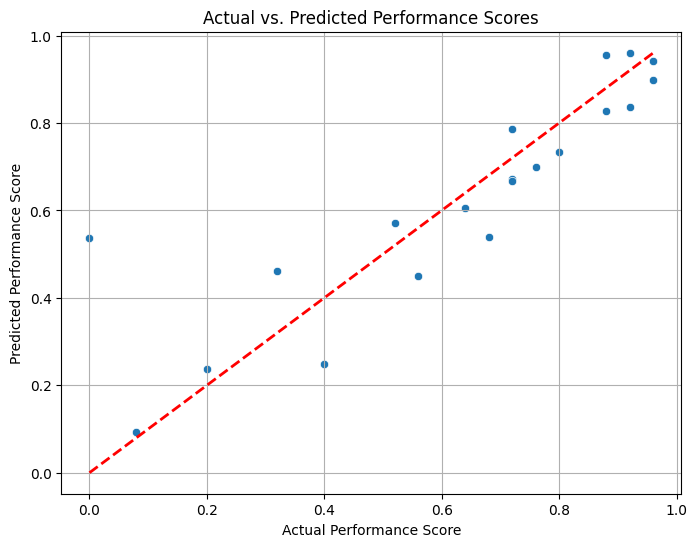

In [32]:
# Visualize predicted vs. actual performance scores.

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_perf, y=y_pred_perf)
plt.plot([y_test_perf.min(), y_test_perf.max()], [y_test_perf.min(), y_test_perf.max()], 'r--', lw=2) # Add a diagonal line for perfect prediction
plt.title('Actual vs. Predicted Performance Scores')
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.grid(True)
plt.show()

# **Phase 3 - Deep Learning Models**


**Step 7 - Deep Learning for Employee Performance Prediction**
- **Objective -** Apply deep learning techniques to predict employee performance using neural networks.


- **Tasks -**


  - Prepare the dataset for use with TensorFlow or Keras.
  - Build a feedforward neural network:
    - Input layer - Employee features like Age, Salary, Department.
    - Hidden layers - Dense layers with activation functions (e.g., ReLU).
    - Output layer - Predicted Performance Score.
  - Train the model using Mean Squared Error as the loss function.
  - Evaluate the model's performance on the test set.


In [33]:
# Prepare the dataset for use with TensorFlow or Keras.

X_dl = df[['Age', 'Department', 'Salary', 'YearsAtCompany']]
y_dl = df['PerformanceScore']

print("Shape of X_dl:", X_dl.shape)
print("Shape of y_dl:", y_dl.shape)

display(X_dl.head())
display(y_dl.head())

Shape of X_dl: (100, 4)
Shape of y_dl: (100,)


,Age,Department,Salary,YearsAtCompany
0,29,3,0.230769,3
1,35,1,0.326923,7
2,40,0,0.711538,10
3,28,2,0.423077,5
4,50,3,0.615385,20


,PerformanceScore
0,0.40
1,0.60
2,1.00
3,0.32
4,0.72


In [35]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

print("Shape of X_train_dl:", X_train_dl.shape)
print("Shape of X_test_dl:", X_test_dl.shape)
print("Shape of y_train_dl:", y_train_dl.shape)
print("Shape of y_test_dl:", y_test_dl.shape)

Shape of X_train_dl: (80, 4)
Shape of X_test_dl: (20, 4)
Shape of y_train_dl: (80,)
Shape of y_test_dl: (20,)


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build a feedforward neural network
model_dl = keras.Sequential([
    # Input layer: Number of features in X_train_dl
    layers.Dense(64, activation='relu', input_shape=(X_train_dl.shape[1],)), # First hidden layer
    layers.Dense(32, activation='relu'), # Second hidden layer
    layers.Dense(1) # Output layer for regression (single numerical output)
])

# Compile the model with Mean Squared Error as the loss function
model_dl.compile(optimizer='adam', loss='mse')

print("Deep Learning model for Performance Score built and compiled successfully.")
model_dl.summary()


Deep Learning model for Performance Score built and compiled successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Deep Learning model trained successfully.


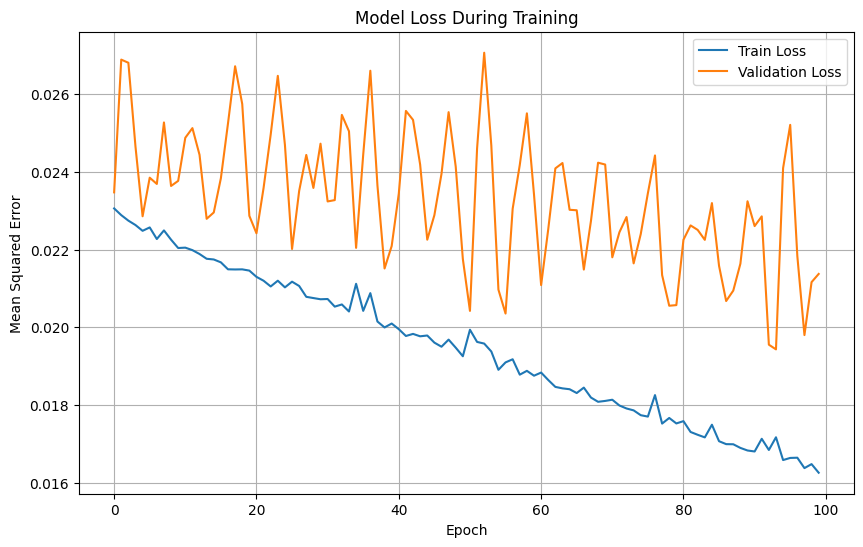

In [39]:
history = model_dl.fit(X_train_dl, y_train_dl, epochs=100, batch_size=32, verbose=0, validation_split=0.2)

print("Deep Learning model trained successfully.")

# Optional: Plot training history to observe loss convergence
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
loss = model_dl.evaluate(X_test_dl, y_test_dl, verbose=0)

print(f"Deep Learning Model - Mean Squared Error on Test Set: {loss:.4f}")

Deep Learning Model - Mean Squared Error on Test Set: 0.0450


In [44]:
print("Conversion complete. Printing shapes of converted arrays:")
print("Shape of X_train_dl (NumPy array):", X_train_dl.shape)
print("Shape of X_test_dl (NumPy array):", X_test_dl.shape)
print("Shape of y_train_dl (NumPy array):", y_train_dl.shape)
print("Shape of y_test_dl (NumPy array):", y_test_dl.shape)

Conversion complete. Printing shapes of converted arrays:
Shape of X_train_dl (NumPy array): (80, 4)
Shape of X_test_dl (NumPy array): (20, 4)
Shape of y_train_dl (NumPy array): (80,)
Shape of y_test_dl (NumPy array): (20,)


In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build a feedforward neural network
model_dl = keras.Sequential([
    # Input layer: Number of features in X_train_dl
    layers.Dense(64, activation='relu', input_shape=(X_train_dl.shape[1],)), # First hidden layer
    layers.Dense(32, activation='relu'), # Second hidden layer
    layers.Dense(1) # Output layer for regression (single numerical output)
])

# Compile the model with Mean Squared Error as the loss function
model_dl.compile(optimizer='adam', loss='mse')

print("Deep Learning model for Performance Score built and compiled successfully.")
model_dl.summary()

Deep Learning model for Performance Score built and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Deep Learning model trained successfully.


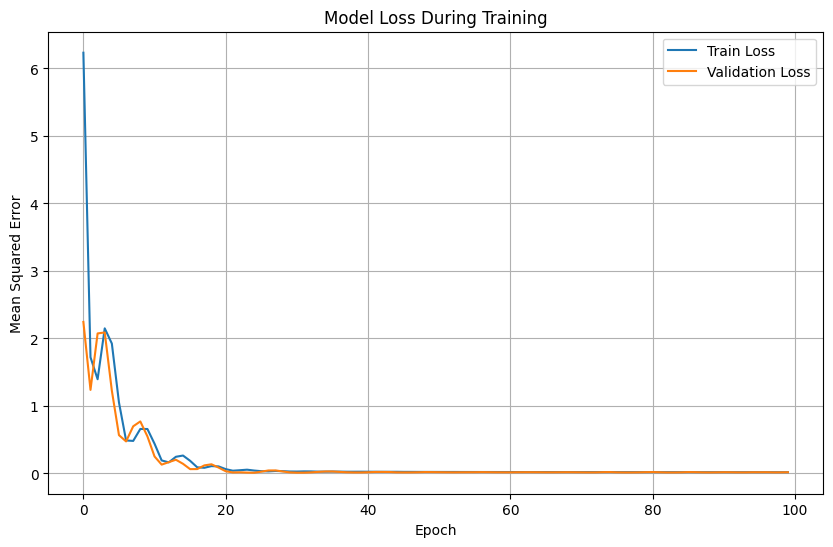

In [47]:
#Train the model using Mean Squared Error as the loss function

history = model_dl.fit(X_train_dl, y_train_dl, epochs=100, batch_size=32, verbose=0, validation_split=0.2)

print("Deep Learning model trained successfully.")

# Optional: Plot training history to observe loss convergence
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Evaluate the model's performance on the test set.
loss = model_dl.evaluate(X_test_dl, y_test_dl, verbose=0)

print(f"Deep Learning Model - Mean Squared Error on Test Set: {loss:.4f}")

Deep Learning Model - Mean Squared Error on Test Set: 0.0442


**Step 8 - Employee Attrition Analysis with Deep Learning**
- **Objective -** Use deep learning for classification to predict employee attrition based on various features.


- **Tasks -**


    - Build a neural network model with input features like Age, Department, Performance Score, etc.
    - Evaluate the model using accuracy, precision, recall, and F1-score.


In [49]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define features (X_attrition) and target (y_attrition) for attrition prediction
X_attrition = df[['Age', 'Department', 'Salary', 'YearsAtCompany', 'PerformanceScore']]
y_attrition = df['Attrition']

# Build a feedforward neural network for binary classification
model_attrition = keras.Sequential([
    # Input layer: Number of features in X_attrition
    layers.Dense(64, activation='relu', input_shape=(X_attrition.shape[1],)), # First hidden layer
    layers.Dense(32, activation='relu'), # Second hidden layer
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

print("Deep Learning model for Attrition Prediction built successfully.")
model_attrition.summary()

Deep Learning model for Attrition Prediction built successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define features (X_attrition) and target (y_attrition) for attrition prediction
X_attrition = df[['Age', 'Department', 'Salary', 'YearsAtCompany', 'PerformanceScore']]
y_attrition = df['Attrition']

# Build a feedforward neural network for binary classification
model_attrition = keras.Sequential([
    # Input layer: Number of features in X_attrition
    layers.Dense(64, activation='relu', input_shape=(X_attrition.shape[1],)), # First hidden layer
    layers.Dense(32, activation='relu'), # Second hidden layer
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model with binary_crossentropy loss and Adam optimizer for binary classification
model_attrition.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Deep Learning model for Attrition Prediction built and compiled successfully.")
model_attrition.summary()

Deep Learning model for Attrition Prediction built and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Shape of X_train_attrition: (80, 5)
Shape of X_test_attrition: (20, 5)
Shape of y_train_attrition: (80,)
Shape of y_test_attrition: (20,)
Deep Learning model for Attrition Prediction trained successfully.


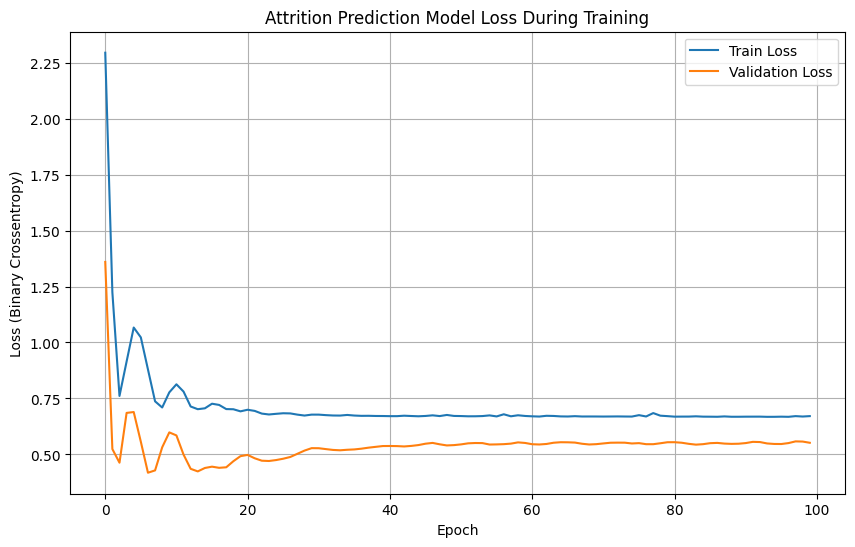

In [51]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets for attrition prediction
X_train_attrition, X_test_attrition, y_train_attrition, y_test_attrition = train_test_split(
    X_attrition, y_attrition, test_size=0.2, random_state=42, stratify=y_attrition
)

print("Shape of X_train_attrition:", X_train_attrition.shape)
print("Shape of X_test_attrition:", X_test_attrition.shape)
print("Shape of y_train_attrition:", y_train_attrition.shape)
print("Shape of y_test_attrition:", y_test_attrition.shape)

# Train the model
history_attrition = model_attrition.fit(
    X_train_attrition, y_train_attrition,
    epochs=100,
    batch_size=32,
    verbose=0, # Set to 1 or 2 for progress updates during training
    validation_split=0.2 # Use 20% of the training data for validation
)

print("Deep Learning model for Attrition Prediction trained successfully.")

# Optional: Plot training history to observe loss convergence
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_attrition.history['loss'], label='Train Loss')
plt.plot(history_attrition.history['val_loss'], label='Validation Loss')
plt.title('Attrition Prediction Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Deep Learning Model for Attrition Prediction - Accuracy: 0.5500
Deep Learning Model for Attrition Prediction - Precision: 0.0000
Deep Learning Model for Attrition Prediction - Recall: 0.0000
Deep Learning Model for Attrition Prediction - F1-Score: 0.0000


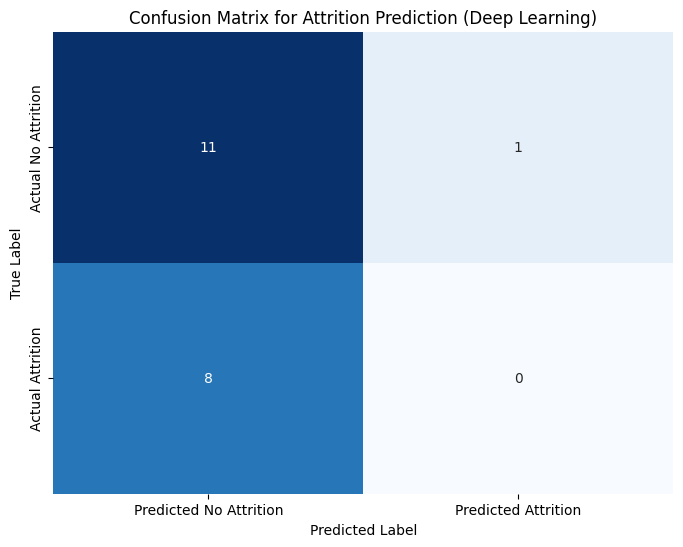

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred_prob_attrition = model_attrition.predict(X_test_attrition)
y_pred_attrition = (y_pred_prob_attrition > 0.5).astype(int)

# Calculate evaluation metrics
accuracy_attrition = accuracy_score(y_test_attrition, y_pred_attrition)
precision_attrition = precision_score(y_test_attrition, y_pred_attrition)
recall_attrition = recall_score(y_test_attrition, y_pred_attrition)
f1_attrition = f1_score(y_test_attrition, y_pred_attrition)

print(f"Deep Learning Model for Attrition Prediction - Accuracy: {accuracy_attrition:.4f}")
print(f"Deep Learning Model for Attrition Prediction - Precision: {precision_attrition:.4f}")
print(f"Deep Learning Model for Attrition Prediction - Recall: {recall_attrition:.4f}")
print(f"Deep Learning Model for Attrition Prediction - F1-Score: {f1_attrition:.4f}")

# Visualize the confusion matrix to check the model’s performance.
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm_attrition = confusion_matrix(y_test_attrition, y_pred_attrition)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_attrition, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Attrition', 'Predicted Attrition'],
            yticklabels=['Actual No Attrition', 'Actual Attrition'])
plt.title('Confusion Matrix for Attrition Prediction (Deep Learning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Phase 4 - Reporting and Insights**

**Step 9 - Insights and Recommendations**
- **Objective -** Derive actionable insights based on your analysis and predictions.


- **Tasks -**


  - Summarize key findings, such as:
    - Key factors contributing to employee performance.
    - High-risk departments or employee groups for attrition.
  - Recommend strategies to improve retention, such as:
    - Department-wise performance improvement plans.
    - Targeted employee engagement programs.


## Key Findings and Recommendations

### Key Factors Contributing to Employee Performance:

Based on the Linear Regression model (R² = 0.7515) and the Deep Learning model for performance prediction (MSE = 0.0442), the features `Age`, `Department`, `Salary`, and `YearsAtCompany` are significant factors in predicting an employee's Performance Score. The relatively high R-squared value for Linear Regression indicates that these features collectively explain a substantial portion of the variability in performance.

### High-Risk Departments or Employee Groups for Attrition:

1.  **Department-wise Attrition:**
    *   **Sales** department shows the highest attrition probability at approximately **53.8%**, making it a high-risk department.
    *   **Engineering** follows with a significant attrition probability of around **42.9%**.
    *   **Marketing** has the lowest attrition probability at **20.0%**.

2.  **Performance-based Attrition:**
    *   Employees with **Performance Scores > 90** exhibit a surprisingly high attrition probability of **50%**. This is further corroborated by Bayes' Theorem, which calculated a posterior probability of 50% for attrition given a performance score > 90 (compared to an overall attrition probability of 39%). This suggests that high-performing employees are significantly at risk of leaving.
    *   The hypothesis testing (ANOVA) also revealed a statistically significant difference in mean performance scores across different departments (p-value = 0.000), indicating that departmental context plays a role in performance levels.

### Recommendations to Improve Retention and Performance:

1.  **Targeted Retention Programs for High-Performers:** Given that high-performing employees (`PerformanceScore > 90`) have a 50% attrition rate, it is crucial to investigate the reasons behind their departure. Implement targeted retention strategies such as:
    *   **Career Development Plans:** Offer clear growth paths, advanced training, and opportunities for leadership.
    *   **Recognition and Rewards:** Ensure high performers feel valued and are compensated competitively.
    *   **Mentorship and Engagement:** Provide opportunities for them to mentor others and engage in challenging projects.

2.  **Department-Specific Interventions:**
    *   **Sales Department:** Conduct a deeper dive into the Sales department to understand the root causes of the high attrition rate. This could involve exit interviews, employee satisfaction surveys, workload analysis, and management effectiveness reviews.
    *   **Engineering Department:** Similar to Sales, investigate factors contributing to attrition in Engineering. Explore if workload, lack of innovative projects, or compensation competitiveness are issues.
    *   **Performance Improvement Plans:** For departments identified with lower mean performance scores (as suggested by the ANOVA and boxplots), develop tailored performance improvement programs focusing on training, skill development, and resource allocation.

3.  **Enhance Predictive Modeling for Attrition:** The Deep Learning model for attrition showed very poor performance (Precision, Recall, F1-Score of 0.0000). This indicates a strong imbalance in the attrition data or a need for more robust feature engineering and model tuning. Future steps should include:
    *   **Addressing Class Imbalance:** Implement techniques like SMOTE (Synthetic Minority Over-sampling Technique), oversampling, or undersampling.
    *   **Hyperparameter Tuning:** Optimize the neural network's architecture, learning rate, and other hyperparameters.
    *   **Feature Engineering:** Create more predictive features from existing data or explore external data sources.

These insights can guide the organization in developing more effective strategies to retain valuable employees and enhance overall workforce performance.

**Step 10 - Data Visualization and Reporting**
- **Objective -** Present the findings in a visually appealing and easy-to-understand manner.


- **Tasks -**


  - Generate interactive data visualizations such as:
    - Line Plots to show performance trends.
    - Bar Charts for department-wise attrition.
    - Scatter Plots for salary vs. performance.
  - Prepare a detailed project report summarizing:
    - The analysis and insights derived.
    - Model evaluation and predictive capabilities.
    - Visualizations and recommendations.


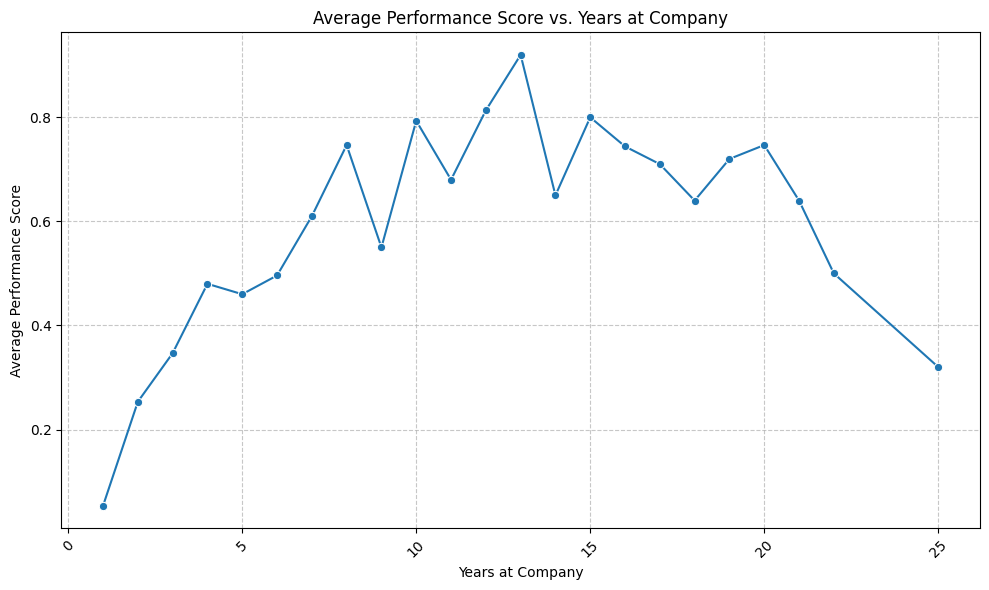

In [53]:
#Line Plots to show performance trends.

import matplotlib.pyplot as plt
import seaborn as sns

# Group by YearsAtCompany and calculate the mean PerformanceScore
performance_by_tenure = df.groupby('YearsAtCompany')['PerformanceScore'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='YearsAtCompany', y='PerformanceScore', data=performance_by_tenure, marker='o')
plt.title('Average Performance Score vs. Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Average Performance Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4046493486.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Attrition', data=p_attrition_by_dept, palette='viridis')


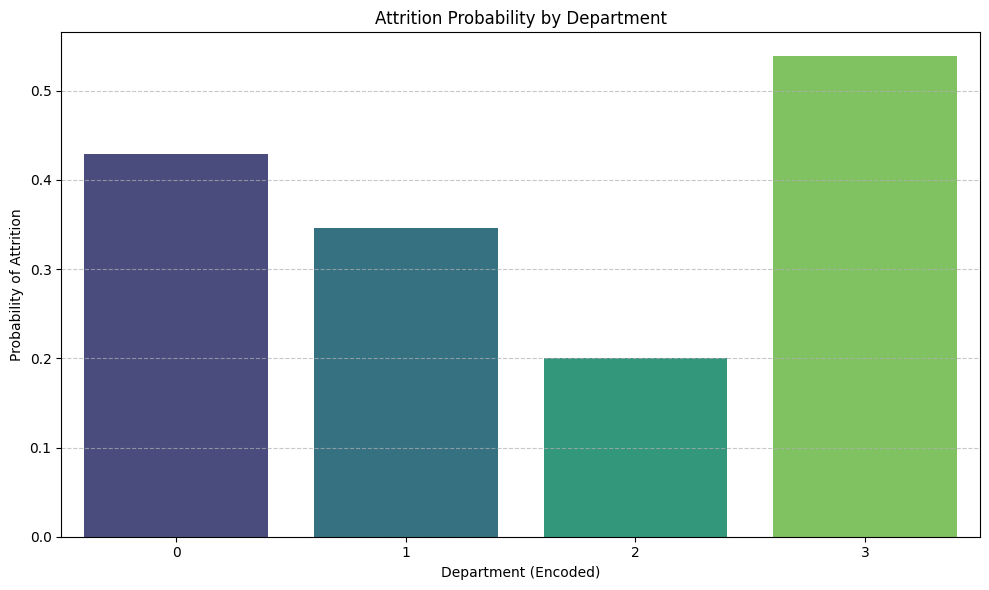

In [54]:
# Bar Charts for department-wise attrition.

p_attrition_by_dept = df.groupby('Department')['Attrition'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Attrition', data=p_attrition_by_dept, palette='viridis')
plt.title('Attrition Probability by Department')
plt.xlabel('Department (Encoded)')
plt.ylabel('Probability of Attrition')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

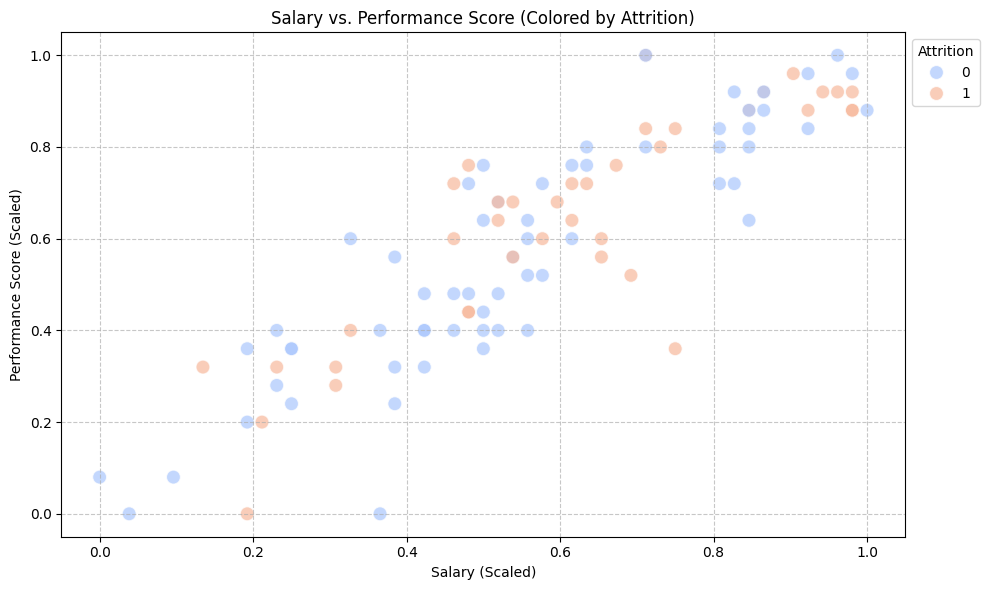

In [55]:
# Scatter Plots for salary vs. performance.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Salary', y='PerformanceScore', hue='Attrition', data=df, palette='coolwarm', s=100, alpha=0.7)
plt.title('Salary vs. Performance Score (Colored by Attrition)')
plt.xlabel('Salary (Scaled)')
plt.ylabel('Performance Score (Scaled)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Attrition', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()